# Reproducible Data Workflow: New York City Airbnb Open Data (2019)

**Name:** _[Your Name Here]_

**Dataset:** New York City Airbnb Open Data (2019) — [Kaggle link](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)

**Project description:** This notebook builds a complete, reproducible data workflow for the 2019
New York City Airbnb listings dataset. The workflow loads the raw listing data, cleans and
transforms it, explores pricing and availability patterns across boroughs and room types, and
visualizes the key relationships in the data. The goal is to demonstrate a modular, documented,
and reusable process that could serve as the foundation for later machine learning or deep
learning work on this data.

## Setup

Import the libraries used throughout this workflow.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook / plotting configuration
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Data Ingestion

The dataset is loaded from `AB_NYC_2019.csv`, which should live in the same folder as this
notebook (see the project README for download instructions).

In [4]:
df = pd.read_csv("AB_NYC_2019.csv")

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 48895 rows x 16 columns


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [6]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## Data Cleaning

A quick audit of the raw data shows two categories of problems that need to be addressed before
any meaningful analysis can be done:

1. **Missing values** — `name` (16 rows) and `host_name` (21 rows) are missing for a small
   number of listings, and `last_review` / `reviews_per_month` are missing for about 10,052
   listings (roughly 20% of the data). The review fields are missing together, which strongly
   suggests they are missing because those listings have simply never been reviewed
   (`number_of_reviews == 0`), not because of a data collection error.
2. **Invalid or extreme outlier values** — 11 listings have a `price` of \$0, which is not a
   realistic nightly rate and likely reflects a data entry error or an inactive listing. A small
   number of listings also report extreme `price` (up to \$10,000/night) and `minimum_nights`
   (up to 1,250 nights) values that sit far outside the bulk of the distribution and would distort
   summary statistics and visualizations if left in place.

Two cleaning functions are defined below to address each issue in a modular, reusable way.

In [4]:
def clean_missing_values(data):
    """
    Handle missing values in the raw Airbnb listings data.

    - `reviews_per_month` is filled with 0 for listings that have never been reviewed
      (missing values here line up with `number_of_reviews == 0`), since a listing with
      no reviews has a review rate of zero rather than an unknown one.
    - `last_review` is converted to a proper datetime type; listings with no reviews are
      left as NaT (missing), since there genuinely is no review date for them.
    - `name` and `host_name` are filled with the placeholder "Unknown" rather than dropped,
      since only a handful of rows are affected and every other field for those rows is
      still usable.

    Parameters
    ----------
    data : pandas.DataFrame
        Raw Airbnb listings data.

    Returns
    -------
    pandas.DataFrame
        A copy of `data` with missing values handled.
    """
    cleaned = data.copy()

    cleaned["reviews_per_month"] = cleaned["reviews_per_month"].fillna(0)
    cleaned["last_review"] = pd.to_datetime(cleaned["last_review"], errors="coerce")
    cleaned["name"] = cleaned["name"].fillna("Unknown")
    cleaned["host_name"] = cleaned["host_name"].fillna("Unknown")

    return cleaned


def remove_outliers(data, price_upper=799, min_nights_upper=45):
    """
    Remove invalid and extreme outlier rows from the Airbnb listings data.

    - Listings with a `price` of 0 are dropped, since a free nightly rate is not a
      realistic value and almost certainly reflects a data error or inactive listing.
    - Listings with `price` above `price_upper` (default: the 99th percentile, $799) are
      dropped, since a small number of ultra-luxury listings would otherwise dominate
      summary statistics and compress the visible spread of typical prices in plots.
    - Listings with `minimum_nights` above `min_nights_upper` (default: the 99th
      percentile, 45 nights) are dropped, since a handful of listings requiring 100+
      nights (up to 1,250) look like long-term/corporate rentals or data errors rather
      than typical short-term stays.

    Parameters
    ----------
    data : pandas.DataFrame
        Airbnb listings data (ideally already passed through `clean_missing_values`).
    price_upper : int or float, default 799
        Upper cutoff for `price`; rows above this value are removed.
    min_nights_upper : int or float, default 45
        Upper cutoff for `minimum_nights`; rows above this value are removed.

    Returns
    -------
    pandas.DataFrame
        A copy of `data` with price/minimum_nights outliers removed.
    """
    cleaned = data.copy()
    cleaned = cleaned[cleaned["price"] > 0]
    cleaned = cleaned[cleaned["price"] <= price_upper]
    cleaned = cleaned[cleaned["minimum_nights"] <= min_nights_upper]

    return cleaned

In [5]:
rows_before = df.shape[0]

df_clean = clean_missing_values(df)
df_clean = remove_outliers(df_clean)

rows_after = df_clean.shape[0]
rows_removed = rows_before - rows_after

print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning:  {rows_after}")
print(f"Rows removed:         {rows_removed} ({rows_removed / rows_before:.1%})")
print()
print("Remaining missing values:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

Rows before cleaning: 48895
Rows after cleaning:  47964
Rows removed:         931 (1.9%)

Remaining missing values:
last_review    9622
dtype: int64


**Cleaning justification.** The two cleaning functions above address the specific data
quality issues identified in the audit. `clean_missing_values` treats the missing `last_review`
and `reviews_per_month` values as *structurally* missing (i.e., missing because the listing has
never been reviewed) rather than as random gaps, so filling `reviews_per_month` with 0 preserves
the correct meaning of "no review activity" instead of introducing a misleading average.
`remove_outliers` removes a small fraction of the data (roughly 2%) corresponding to \$0 listings,
ultra-luxury prices, and unrealistic minimum-night requirements; leaving these values in would
have inflated the mean price, compressed the visible range of typical listings in histograms, and
made borough-level comparisons harder to read. Percentile-based cutoffs (99th percentile) were
used instead of a fixed threshold so that the cutoffs are grounded in the actual distribution of
this dataset rather than an arbitrary guess.

## Exploratory Data Analysis

The function below produces a compact exploratory summary: overall descriptive statistics for
the numeric columns, average price and listing count by borough, and the correlation matrix
between the key numeric features.

In [6]:
def exploratory_summary(data):
    """
    Produce a compact exploratory-analysis summary for the Airbnb listings data.

    Computes three views of the data:
    1. Descriptive statistics (count, mean, std, min/max, quartiles) for the main
       numeric columns.
    2. Average price and listing count grouped by `neighbourhood_group` (borough).
    3. The correlation matrix between the numeric features, useful for spotting
       linear relationships worth visualizing.

    Parameters
    ----------
    data : pandas.DataFrame
        Cleaned Airbnb listings data.

    Returns
    -------
    dict of {str: pandas.DataFrame}
        A dictionary with keys "describe", "by_borough", and "correlation", each
        holding the corresponding summary DataFrame.
    """
    numeric_cols = [
        "price", "minimum_nights", "number_of_reviews",
        "reviews_per_month", "calculated_host_listings_count", "availability_365",
    ]

    describe_summary = data[numeric_cols].describe().round(2)

    by_borough = (
        data.groupby("neighbourhood_group")
        .agg(listing_count=("id", "count"), avg_price=("price", "mean"))
        .round(2)
        .sort_values("avg_price", ascending=False)
    )

    correlation = data[numeric_cols].corr().round(2)

    return {"describe": describe_summary, "by_borough": by_borough, "correlation": correlation}


eda_results = exploratory_summary(df_clean)

In [7]:
print("Descriptive statistics:")
eda_results["describe"]

Descriptive statistics:


,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,47964.00,47964.00,47964.00,47964.00,47964.00,47964.00
mean,137.64,5.74,23.54,1.10,7.18,111.49
std,103.90,8.45,44.81,1.61,33.11,131.01
min,10.00,1.00,0.00,0.00,1.00,0.00
25%,69.00,1.00,1.00,0.04,1.00,0.00
50%,105.00,2.00,5.00,0.38,1.00,43.00
75%,175.00,5.00,24.00,1.62,2.00,222.25
max,799.00,45.00,629.00,58.50,327.00,365.00


In [8]:
print("Average price and listing count by borough:")
eda_results["by_borough"]

Average price and listing count by borough:


,listing_count,avg_price
neighbourhood_group,,
Manhattan,21063,173.13
Brooklyn,19836,115.97
Staten Island,368,94.23
Queens,5622,94.20
Bronx,1075,84.03


In [9]:
print("Correlation matrix:")
eda_results["correlation"]

Correlation matrix:


,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
price,1.00,0.05,-0.06,-0.05,0.15,0.11
minimum_nights,0.05,1.00,-0.15,-0.22,0.32,0.24
number_of_reviews,-0.06,-0.15,1.00,0.59,-0.07,0.18
reviews_per_month,-0.05,-0.22,0.59,1.00,-0.05,0.17
calculated_host_listings_count,0.15,0.32,-0.07,-0.05,1.00,0.23
availability_365,0.11,0.24,0.18,0.17,0.23,1.00


The borough-level breakdown shows that Manhattan has both the highest listing count and by far
the highest average price, while the correlation matrix shows only weak linear relationships
between most numeric features — for example, `number_of_reviews` and `reviews_per_month` are
positively correlated with each other (as expected) but only weakly correlated with `price`,
suggesting that pricing in this dataset is driven mainly by categorical factors (borough, room
type) rather than by review activity.

## Visualizations

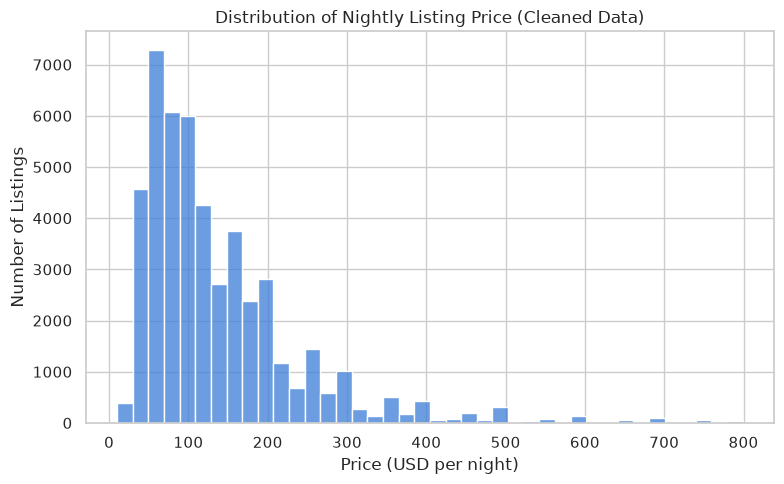

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_clean["price"], bins=40, color="#3b7dd8", ax=ax)
ax.set_title("Distribution of Nightly Listing Price (Cleaned Data)")
ax.set_xlabel("Price (USD per night)")
ax.set_ylabel("Number of Listings")
plt.tight_layout()
plt.show()

**Interpretation:** Prices are right-skewed even after removing the most extreme outliers — most
listings are priced under \$150/night, with a long tail of pricier listings stretching toward the
\$799 cutoff used during cleaning.

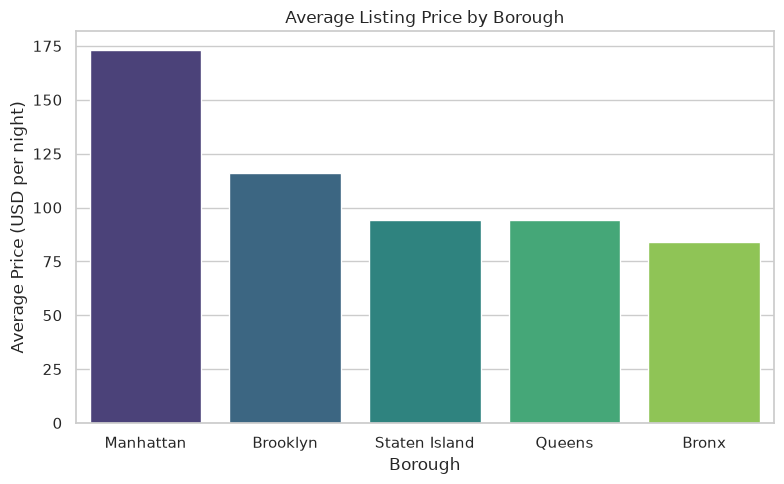

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
borough_order = eda_results["by_borough"].index
sns.barplot(
    x=borough_order,
    y=eda_results["by_borough"]["avg_price"],
    hue=borough_order,
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.set_title("Average Listing Price by Borough")
ax.set_xlabel("Borough")
ax.set_ylabel("Average Price (USD per night)")
plt.tight_layout()
plt.show()

**Interpretation:** Manhattan listings are the most expensive on average by a wide margin,
followed by Brooklyn; the Bronx, Queens, and Staten Island cluster together at meaningfully lower
average prices — a pattern broadly consistent with each borough's cost of living and tourist
demand.

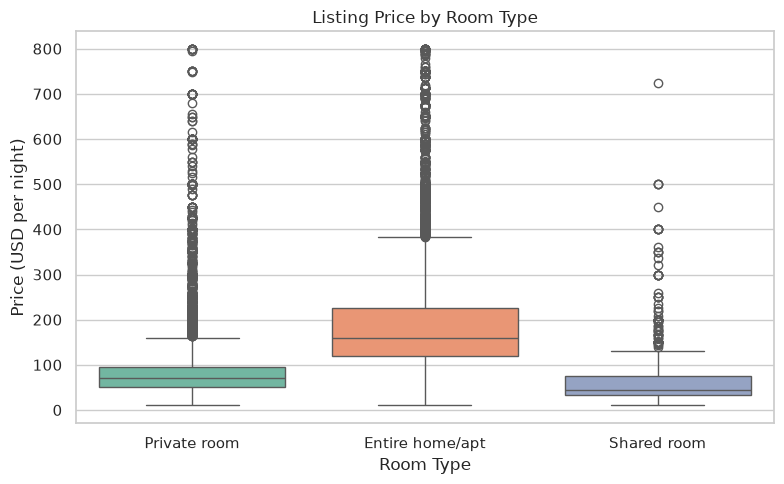

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df_clean, x="room_type", y="price",
    hue="room_type", palette="Set2", legend=False, ax=ax,
)
ax.set_title("Listing Price by Room Type")
ax.set_xlabel("Room Type")
ax.set_ylabel("Price (USD per night)")
plt.tight_layout()
plt.show()

**Interpretation:** Entire homes/apartments command a clear price premium over private and
shared rooms, and also show the widest spread — consistent with entire-unit listings ranging
from modest apartments to large luxury homes.

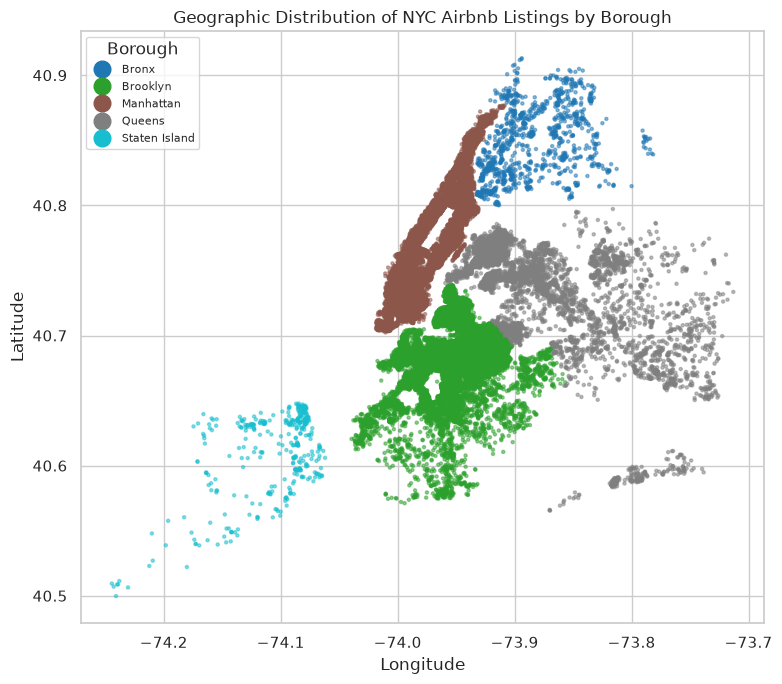

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(
    df_clean["longitude"], df_clean["latitude"],
    c=df_clean["neighbourhood_group"].astype("category").cat.codes,
    cmap="tab10", s=5, alpha=0.5,
)
ax.set_title("Geographic Distribution of NYC Airbnb Listings by Borough")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
categories = df_clean["neighbourhood_group"].astype("category").cat.categories
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=plt.cm.tab10(i / max(len(categories) - 1, 1)))
    for i in range(len(categories))
]
ax.legend(handles, categories, title="Borough", loc="upper left", markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation:** Plotting each listing's coordinates reproduces the recognizable shape of New
York City and shows that listings are heavily concentrated in Manhattan and Brooklyn, with far
sparser coverage in the Bronx, Queens, and especially Staten Island — mirroring the listing counts
seen in the borough summary table above.

## Summary & Interpretation

This workflow cleaned and explored the 2019 New York City Airbnb listings dataset, starting from
48,895 raw listings and retaining about 98% of them after removing invalid \$0 prices and a small
number of extreme price/minimum-night outliers. The most consistent pattern in the data is a
strong borough effect: Manhattan and Brooklyn together account for the large majority of listings
and command the highest average prices, while the Bronx and Staten Island have far fewer listings
at noticeably lower prices. Room type is the other major driver of price — entire homes and
apartments are priced well above private or shared rooms — while review activity
(`number_of_reviews`, `reviews_per_month`) shows only a weak linear relationship with price,
suggesting that how "popular" a listing is does not, by itself, explain what it costs.

A few assumptions and limitations are worth noting. First, the missing `last_review` and
`reviews_per_month` values were assumed to mean "never reviewed" rather than "data not collected";
this is a reasonable assumption for this dataset but was not independently verified against an
outside source. Second, outlier removal used fixed percentile cutoffs (99th percentile for both
`price` and `minimum_nights`); a different analysis goal (e.g., specifically studying luxury
listings) would call for different, or no, cutoffs. Third, this snapshot reflects listings as of
2019 and does not capture how the short-term rental market in NYC has changed since local
regulations tightened in later years, so the patterns here should not be assumed to hold today.
Finally, the geographic scatter plot is a useful sanity check on the data's structure but is not a
substitute for a proper choropleth or density map for deeper spatial analysis.